In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
pearson = df.corr(method="pearson")
print(pearson)

             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp      0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1      0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2      0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3     -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4      0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5      0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6      0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
Target  0.187889  0.043062  0.586450  0.441482  0.212022  0.174054 -0.394789   

              s4        s5        s6   

In [4]:
spearman = df.corr(method="spearman")
print(spearman)

             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.177463  0.200554  0.350859  0.262524  0.221711 -0.106973   
sex     0.177463  1.000000  0.098079  0.261508  0.027790  0.134695 -0.394584   
bmi     0.200554  0.098079  1.000000  0.397985  0.287829  0.295494 -0.371172   
bp      0.350859  0.261508  0.397985  1.000000  0.275224  0.205638 -0.191033   
s1      0.262524  0.027790  0.287829  0.275224  1.000000  0.878793  0.015308   
s2      0.221711  0.134695  0.295494  0.205638  0.878793  1.000000 -0.197435   
s3     -0.106973 -0.394584 -0.371172 -0.191033  0.015308 -0.197435  1.000000   
s4      0.221017  0.337524  0.459068  0.280799  0.520674  0.652283 -0.789694   
s5      0.265176  0.174625  0.491609  0.396071  0.512864  0.349947 -0.450420   
s6      0.296235  0.203277  0.384664  0.381219  0.332173  0.286483 -0.290863   
Target  0.197822  0.037401  0.561382  0.416241  0.232429  0.195834 -0.410022   

              s4        s5        s6   

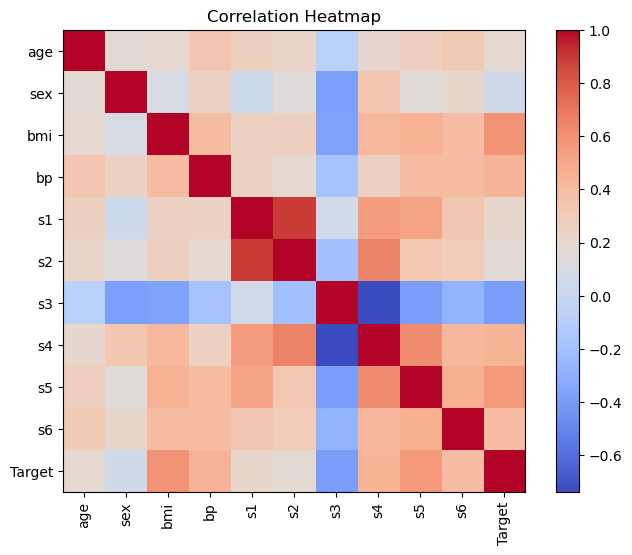

In [5]:
plt.figure(figsize=(8,6))
plt.imshow(pearson, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Heatmap")
plt.show()

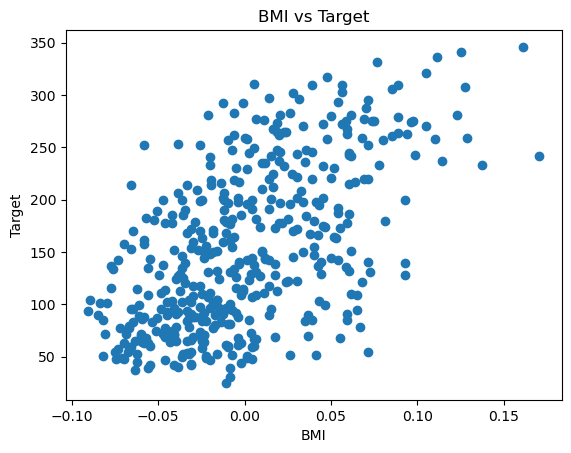

In [6]:
plt.scatter(df["bmi"], df["Target"])
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.show()

In [7]:
X = df[["bmi"]]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.23335039815872138
MAE: 52.25997644534553
RMSE: 63.73245584860925


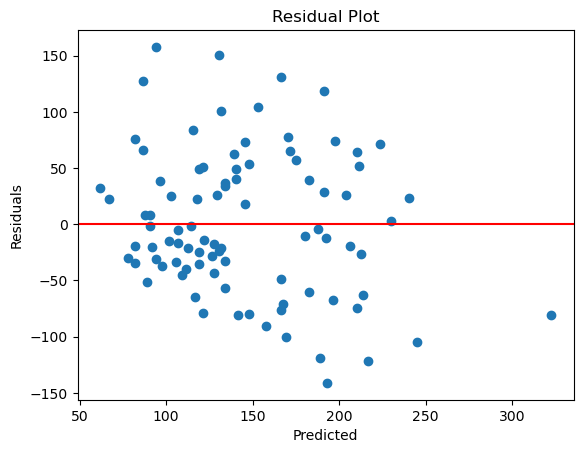

In [9]:
residuals = y_test - pred

plt.scatter(pred, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()